# Seaborn

<p align="center">
  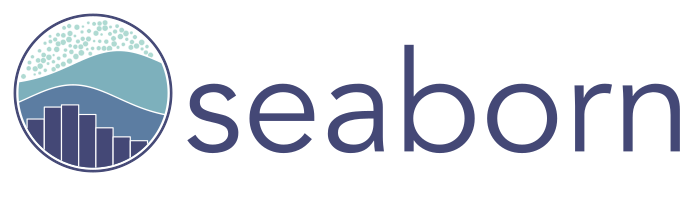
</p>

**Autores:** Moisés Velasco Lozano &nbsp;&middot;&nbsp; Josué Heber Fabián Martínez


<table width="100%">
<tr>
<td bgcolor="#E3F2FD">

# <font color="blue">**1. Introducción**</font>

</td>
</tr>
</table>

Seaborn es una biblioteca de Python para visualización estadística de datos, construida sobre Matplotlib e integrada de forma nativa con Pandas. Su objetivo es facilitar la creación de gráficos estadísticos complejos (distribuciones, relaciones entre variables, comparaciones categóricas) con muy pocas líneas de código, aplicando automáticamente estilos visuales cuidados.

Entre sus principales ventajas frente a Matplotlib "puro" se encuentran:

* Funciones de alto nivel orientadas a **DataFrames** (se le pasa el DataFrame y los nombres de columnas, no arreglos sueltos).
* Cálculo automático de estadísticas (regresiones, intervalos de confianza, distribuciones) sin necesidad de calcularlas manualmente.
* Paletas de color y temas predefinidos pensados para comunicar datos de forma clara.
* Herramientas para graficar relaciones **multivariadas** en una sola llamada (`pairplot`, `relplot`, `catplot`, `FacetGrid`).

En este notebook aplicaremos Seaborn a un caso típico de **geociencias / industria petrolera**: el análisis exploratorio de un registro de pozos (well log) con propiedades petrofísicas (porosidad, permeabilidad, saturación de agua, litología) y datos de producción.

https://seaborn.pydata.org/

https://seaborn.pydata.org/tutorial.html

**Nota:** los enlaces incluidos en este notebook (documentación oficial de Seaborn y su tutorial) son solo material de consulta para quien lea el notebook — no es necesario abrirlos para poder ejecutar o entender el código.

<table width="100%">
<tr>
<td bgcolor="#E3F2FD">

# <font color="blue">**2. Preparación de los datos**</font>

</td>
</tr>
</table>

### 2.1 Importar librerías

In [77]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

**Explicación:** se importan `pandas` y `numpy` para el manejo de datos, `seaborn` (con el alias estándar `sns`) para las visualizaciones estadísticas, y `matplotlib.pyplot` que Seaborn usa como motor de graficado por debajo y que permite ajustes finos adicionales (tamaño de figura, títulos, etc.).

### 2.2 Simulación de un dataset de registro de pozos

Construiremos un DataFrame que simula un **well log** (registro de pozo) con las propiedades petrofísicas más comunes, para 4 pozos con distinta litología dominante. Esta será la base de datos que usaremos en la mayoría de los gráficos del notebook.

In [78]:
np.random.seed(42)

pozos = ['Pozo-A1', 'Pozo-A2', 'Pozo-B1', 'Pozo-B3']
litologia_por_pozo = {'Pozo-A1': 'Arenisca', 'Pozo-A2': 'Arenisca', 'Pozo-B1': 'Caliza', 'Pozo-B3': 'Lutita'}
n_muestras = 150

registros = []
for pozo in pozos:
    lito = litologia_por_pozo[pozo]
    base_poro = {'Arenisca': 18, 'Caliza': 12, 'Lutita': 6}[lito]
    base_perm = {'Arenisca': 180, 'Caliza': 60, 'Lutita': 2}[lito]

    profundidad = np.sort(np.random.uniform(2000, 2600, n_muestras))
    porosidad = np.clip(np.random.normal(base_poro, 3.5, n_muestras), 1, 32)
    permeabilidad = np.clip(base_perm * np.exp(porosidad / 10) / 10 + np.random.normal(0, base_perm*0.15, n_muestras), 0.01, None)
    sw = np.clip(70 - porosidad * 1.8 + np.random.normal(0, 6, n_muestras), 5, 95)
    rho = np.clip(2.65 - porosidad/100*0.9 + np.random.normal(0, 0.03, n_muestras), 1.9, 2.7)

    df_pozo = pd.DataFrame({
        'Pozo': pozo,
        'Litologia': lito,
        'Profundidad_m': profundidad,
        'Porosidad_pct': porosidad,
        'Permeabilidad_mD': permeabilidad,
        'Sw_pct': sw,
        'Densidad_g_cm3': rho
    })
    registros.append(df_pozo)

df_log = pd.concat(registros, ignore_index=True)
df_log.head()

,Pozo,Litologia,Profundidad_m,Porosidad_pct,Permeabilidad_mD,Sw_pct,Densidad_g_cm3
0,Pozo-A1,Arenisca,2003.313270,17.326737,94.984255,40.805758,2.530096
1,Pozo-A1,Arenisca,2004.171278,19.055416,87.324712,31.209333,2.466259
2,Pozo-A1,Arenisca,2012.350697,17.878509,151.653802,47.125596,2.427950
3,Pozo-A1,Arenisca,2015.251476,13.909627,33.723088,45.656719,2.494571
4,Pozo-A1,Arenisca,2018.857511,21.999880,150.567090,37.475999,2.395877


**Explicación:** se simulan 150 muestras por pozo (600 en total) para 4 pozos con litología dominante distinta (arenisca, caliza y lutita), generando porosidad, permeabilidad, saturación de agua y densidad con rangos característicos de cada litología. El resultado es el DataFrame `df_log`, que tiene una fila por muestra y columnas para cada propiedad — el formato "largo" (*long format*) que Seaborn aprovecha mejor.

In [79]:
np.random.seed(7)
meses = np.arange(0, 36)
qi = {'Pozo-A1': 850, 'Pozo-A2': 620, 'Pozo-B1': 1100, 'Pozo-B3': 400}
Di = {'Pozo-A1': 0.06, 'Pozo-A2': 0.045, 'Pozo-B1': 0.08, 'Pozo-B3': 0.03}

filas_prod = []
for pozo in pozos:
    q0, d = qi[pozo], Di[pozo]
    caudal = q0 * np.exp(-d * meses) + np.random.normal(0, q0 * 0.03, len(meses))
    for m, q in zip(meses, caudal):
        filas_prod.append({'Pozo': pozo, 'Litologia': litologia_por_pozo[pozo], 'Mes': m, 'Caudal_bbl_dia': max(q, 0)})

df_produccion = pd.DataFrame(filas_prod)
df_produccion.head()

,Pozo,Litologia,Mes,Caudal_bbl_dia
0,Pozo-A1,Arenisca,0,893.108405
1,Pozo-A1,Arenisca,1,788.618451
2,Pozo-A1,Arenisca,2,754.719285
3,Pozo-A1,Arenisca,3,720.371345
4,Pozo-A1,Arenisca,4,648.516145


**Explicación:** de forma análoga al notebook de Matplotlib, se simula la curva de declinación de producción (modelo exponencial) de los 4 pozos durante 36 meses, pero esta vez en formato largo (`df_produccion`), con una fila por combinación de pozo y mes — el formato que requieren funciones como `sns.lineplot` o `sns.relplot` para calcular bandas de incertidumbre automáticamente.

<table width="100%">
<tr>
<td bgcolor="#E3F2FD">

# <font color="blue">**3. Estilos y temas visuales**</font>

</td>
</tr>
</table>

Seaborn permite fijar un "tema" global con `sns.set_theme()`, que controla el estilo de fondo, la paleta de colores y la escala de los elementos (tamaño de letra, líneas, etc.) para **todos** los gráficos que se hagan después. Esto evita tener que repetir configuraciones de estilo en cada gráfico.

Parámetros principales:

* `style`: `'darkgrid'`, `'whitegrid'`, `'dark'`, `'white'`, `'ticks'`.
* `palette`: paleta de colores por defecto (`'deep'`, `'muted'`, `'viridis'`, etc.), o una lista/paleta personalizada.
* `context`: escala de los elementos (`'paper'`, `'notebook'`, `'talk'`, `'poster'`).

In [80]:
sns.set_theme(style='whitegrid', palette='deep', context='notebook', font_scale=1.05)

paleta_litologia = {'Arenisca': '#E9C46A', 'Caliza': '#2A9D8F', 'Lutita': '#264653'}
paleta_pozos = {'Pozo-A1': '#FF006E', 'Pozo-A2': '#FB5607', 'Pozo-B1': '#3A86FF', 'Pozo-B3': '#8338EC'}

**Explicación:** se fija el tema global (`whitegrid`: fondo blanco con cuadrícula, paleta `deep`) que aplicará a todos los gráficos siguientes, y se definen dos diccionarios de colores personalizados —uno por litología y otro por pozo— para mantener el mismo color asociado a cada categoría en todo el notebook.

<table width="100%">
<tr>
<td bgcolor="#E3F2FD">

# <font color="blue">**4. Gráficos de distribución**</font>

</td>
</tr>
</table>

**Teoría**

Los gráficos de distribución muestran cómo se reparten los valores de una variable continua. Seaborn ofrece varias funciones para esto, todas más flexibles que `plt.hist()`: `histplot` (histograma), `kdeplot` (estimación de densidad por kernel, una curva suavizada) y `displot` (interfaz de figura completa que puede combinar ambos y separar por categoría con `hue`).

### 4.1 Histograma de porosidad por litología (histplot)

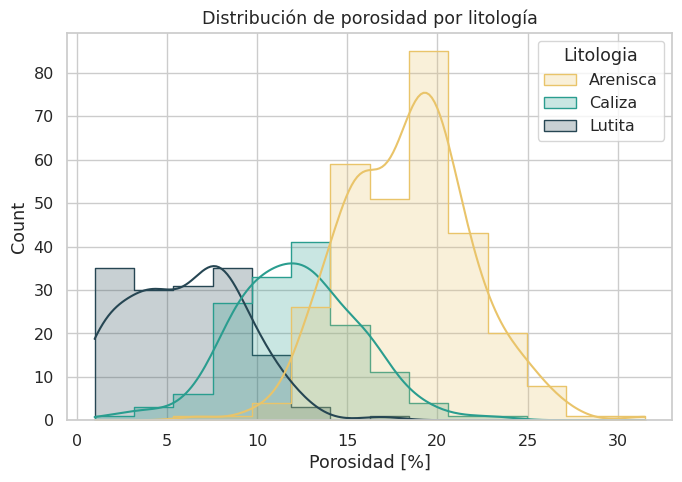

In [81]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.histplot(data=df_log, x='Porosidad_pct', hue='Litologia', palette=paleta_litologia,
             kde=True, element='step', ax=ax)
ax.set_title('Distribución de porosidad por litología')
ax.set_xlabel('Porosidad [%]')
plt.tight_layout()
plt.show()

**Explicación:** `sns.histplot` grafica el histograma de porosidad, separando automáticamente por litología mediante `hue` (cada color corresponde a una litología, usando la paleta personalizada) y superponiendo una curva de densidad (`kde=True`). Se observa claramente cómo la arenisca concentra los valores más altos de porosidad, seguida de la caliza y la lutita.

### 4.2 Densidad de permeabilidad (kdeplot)

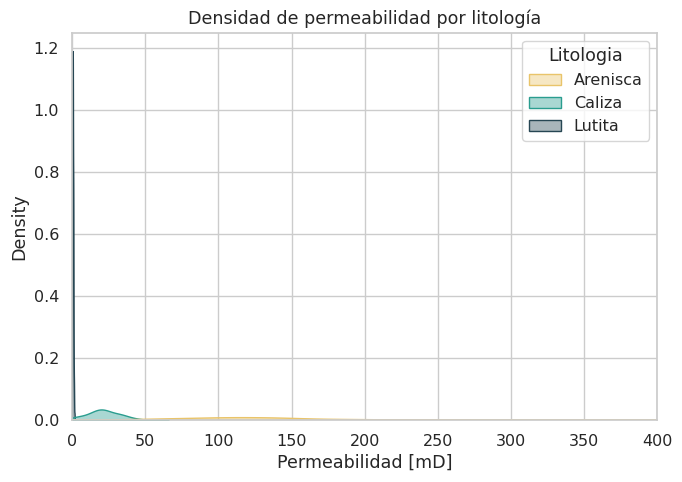

In [82]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.kdeplot(data=df_log, x='Permeabilidad_mD', hue='Litologia', palette=paleta_litologia,
            fill=True, alpha=0.4, common_norm=False, ax=ax)
ax.set_title('Densidad de permeabilidad por litología')
ax.set_xlabel('Permeabilidad [mD]')
ax.set_xlim(0, 400)
plt.tight_layout()
plt.show()

**Explicación:** `sns.kdeplot` estima y grafica la densidad de probabilidad de la permeabilidad para cada litología (`fill=True` rellena el área bajo la curva). `common_norm=False` normaliza cada curva de forma independiente, para comparar la *forma* de la distribución de cada litología sin que el tamaño de muestra afecte la comparación.

### 4.3 displot: histograma + KDE en paneles separados

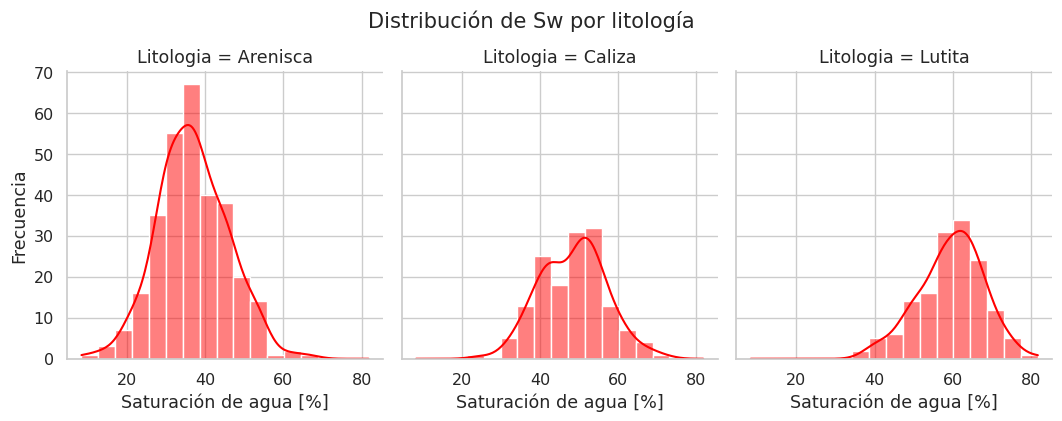

In [83]:
g = sns.displot(data=df_log, x='Sw_pct', col='Litologia', kde=True,
                 color='red', height=4, aspect=0.9)
g.set_axis_labels('Saturación de agua [%]', 'Frecuencia')
g.fig.suptitle('Distribución de Sw por litología', y=1.05)
plt.show()

**Explicación:** a diferencia de `histplot`/`kdeplot` (que dibujan sobre un `ax` existente), `displot` es una función de **figura completa**: con `col='Litologia'` genera automáticamente un panel (subgráfico) por cada litología, facilitando comparar la distribución de la saturación de agua sin superponer curvas.

<table width="100%">
<tr>
<td bgcolor="#E3F2FD">

# <font color="blue">**5. Gráficos de relación**</font>

</td>
</tr>
</table>

**Teoría**

Estos gráficos exploran cómo se relacionan dos o más variables continuas entre sí. `scatterplot` es el equivalente de `plt.scatter()` pero con soporte nativo para colorear (`hue`), cambiar el tamaño (`size`) o la forma (`style`) de los puntos según una tercera o cuarta variable categórica/continua. `regplot`/`lmplot` añaden automáticamente una línea de regresión con su intervalo de confianza.

### 5.1 Crossplot Porosidad–Permeabilidad (scatterplot)

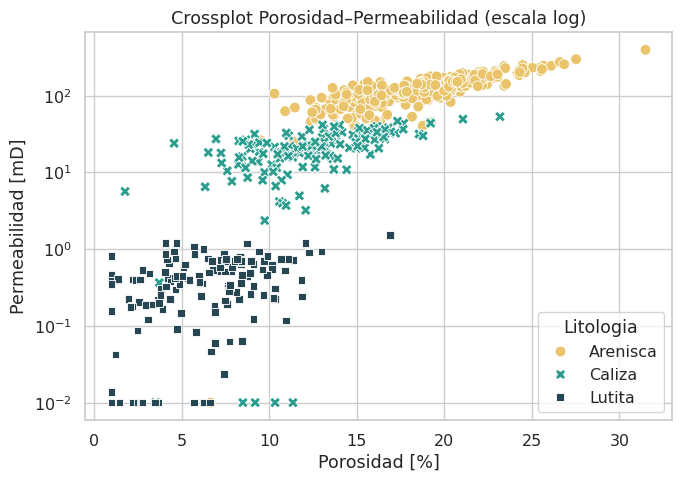

In [84]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df_log, x='Porosidad_pct', y='Permeabilidad_mD',
                 hue='Litologia', style='Litologia', palette=paleta_litologia, s=60, ax=ax)
ax.set_yscale('log')
ax.set_title('Crossplot Porosidad–Permeabilidad (escala log)')
ax.set_xlabel('Porosidad [%]')
ax.set_ylabel('Permeabilidad [mD]')
plt.tight_layout()
plt.show()

**Explicación:** se grafica el crossplot clásico de petrofísica (porosidad vs. permeabilidad, con el eje Y en escala logarítmica), coloreando y cambiando el marcador según la litología (`hue`/`style`), lo que permite identificar de un vistazo que la arenisca tiene mejor calidad de roca (mayor porosidad y permeabilidad) que la lutita.

### 5.2 Regresión lineal por litología (lmplot)

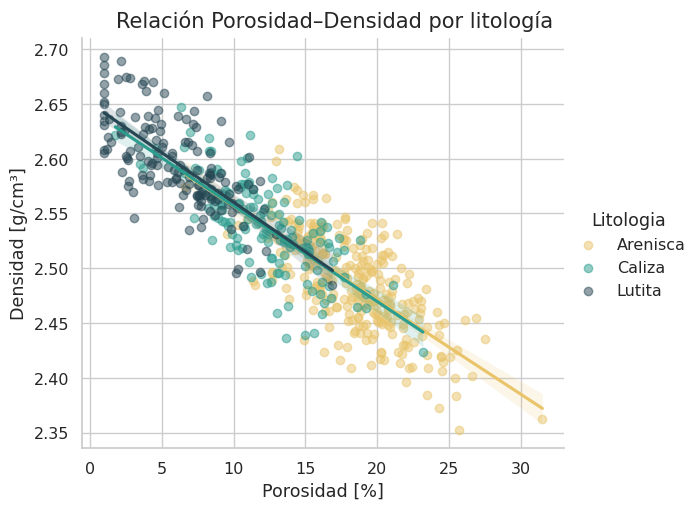

In [85]:
g = sns.lmplot(data=df_log, x='Porosidad_pct', y='Densidad_g_cm3', hue='Litologia',
                palette=paleta_litologia, height=5, aspect=1.2, scatter_kws={'alpha': 0.5})
g.set_axis_labels('Porosidad [%]', 'Densidad [g/cm³]')
g.fig.suptitle('Relación Porosidad–Densidad por litología', y=1.02)
plt.show()

**Explicación:** `sns.lmplot` grafica automáticamente una recta de regresión lineal (con su banda de confianza sombreada) para cada litología, permitiendo comparar visualmente la relación porosidad–densidad —fundamental para calibrar registros de densidad en petrofísica— entre los distintos tipos de roca.

### 5.3 Relaciones múltiples (pairplot)

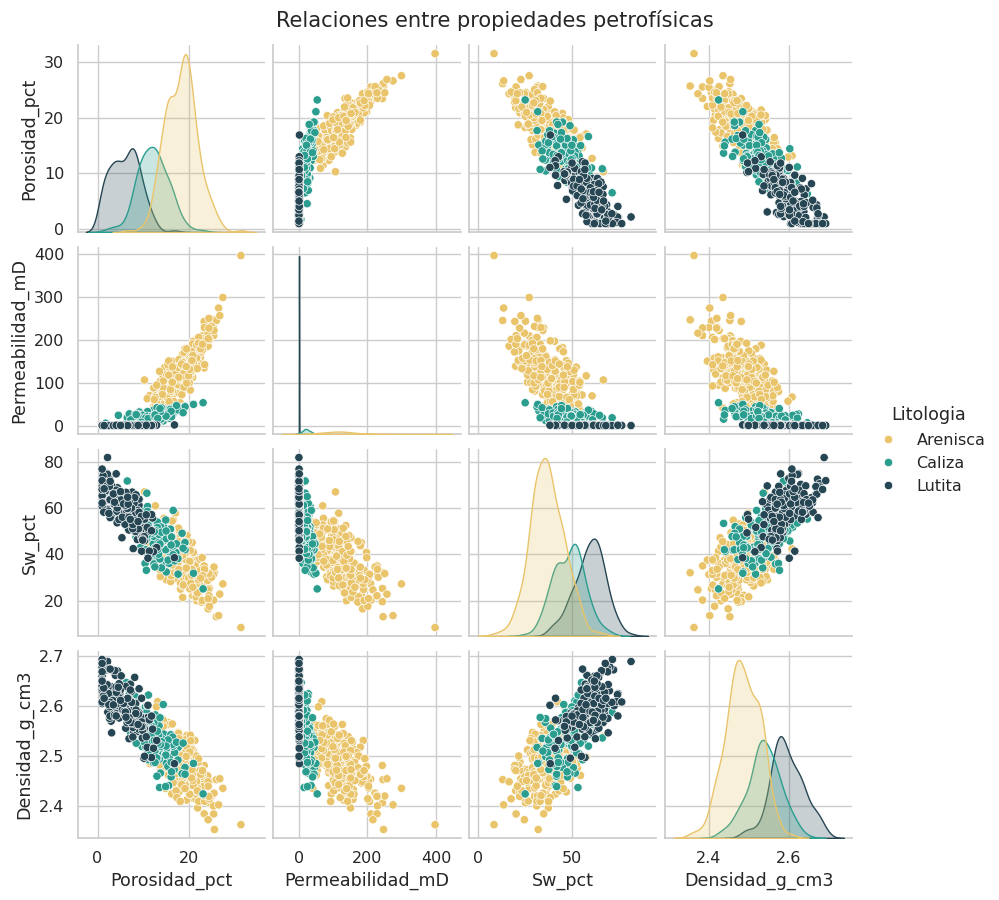

In [86]:
g = sns.pairplot(df_log[['Porosidad_pct', 'Permeabilidad_mD', 'Sw_pct', 'Densidad_g_cm3', 'Litologia']],
                  hue='Litologia', palette=paleta_litologia, diag_kind='kde', height=2.2)
g.fig.suptitle('Relaciones entre propiedades petrofísicas', y=1.02)
plt.show()

**Explicación:** `sns.pairplot` genera automáticamente una matriz de gráficos de dispersión para todas las combinaciones de variables numéricas (con las densidades KDE en la diagonal), coloreadas por litología. Es una de las formas más rápidas de hacer un análisis exploratorio multivariado completo con una sola línea de código.

<table width="100%">
<tr>
<td bgcolor="#E3F2FD">

# <font color="blue">**6. Gráficos categóricos**</font>

</td>
</tr>
</table>

**Teoría**

Estos gráficos comparan una variable numérica entre distintas categorías. `boxplot` y `violinplot` muestran la distribución completa (mediana, cuartiles, forma), mientras que `barplot` resume con una estadística central (por defecto la media) y su intervalo de confianza. `stripplot`/`swarmplot` muestran los datos individuales.

### 6.1 Producción por pozo (boxplot)

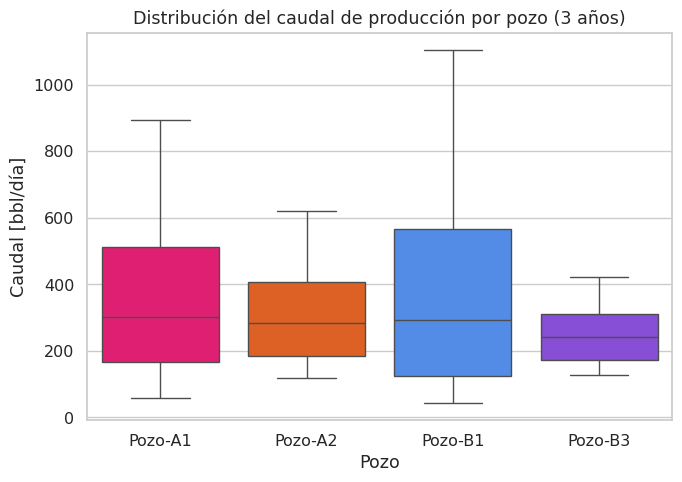

In [87]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df_produccion, x='Pozo', y='Caudal_bbl_dia', hue='Pozo',
            palette=paleta_pozos, legend=False, ax=ax)
ax.set_title('Distribución del caudal de producción por pozo (3 años)')
ax.set_ylabel('Caudal [bbl/día]')
plt.tight_layout()
plt.show()

**Explicación:** se compara la distribución del caudal de producción de los 3 años simulados entre los 4 pozos; cada caja resume la mediana, el rango intercuartílico y los valores atípicos, de forma mucho más compacta que en el notebook de Matplotlib (una sola línea vs. el ciclo manual de colores).

### 6.2 Distribución detallada (violinplot)

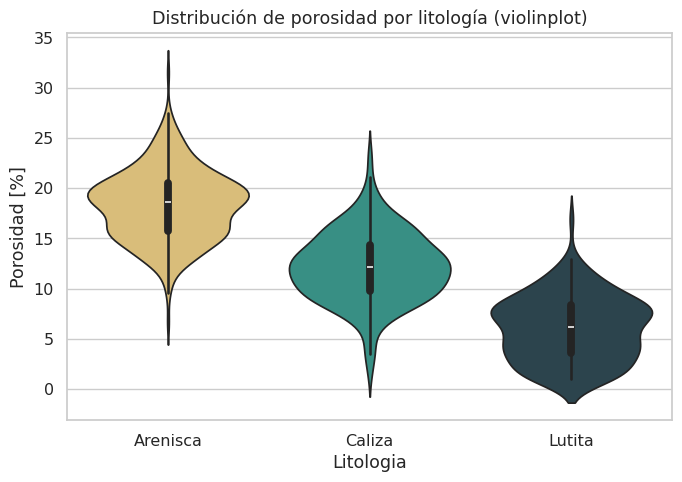

In [88]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.violinplot(data=df_log, x='Litologia', y='Porosidad_pct', hue='Litologia',
               palette=paleta_litologia, legend=False, ax=ax)
ax.set_title('Distribución de porosidad por litología (violinplot)')
ax.set_ylabel('Porosidad [%]')
plt.tight_layout()
plt.show()

**Explicación:** el `violinplot` combina un boxplot con una curva de densidad (KDE) reflejada, mostrando no solo la mediana y el rango sino la **forma completa** de la distribución de porosidad de cada litología (por ejemplo, si es bimodal).

### 6.3 Caudal promedio con intervalo de confianza (barplot)

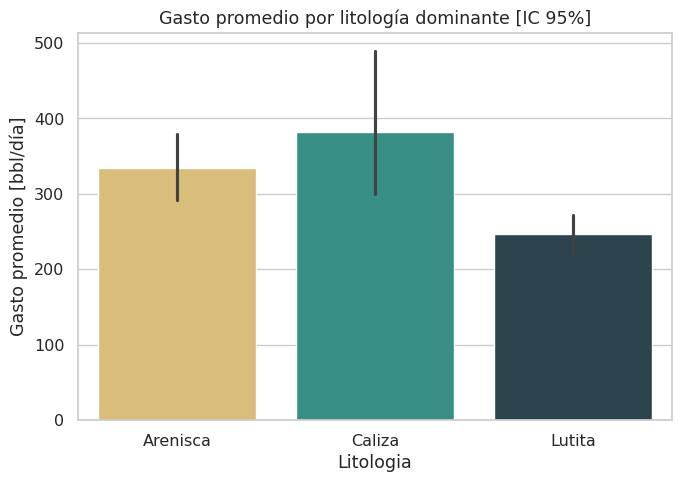

In [89]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=df_produccion, x='Litologia', y='Caudal_bbl_dia', hue='Litologia',
            palette=paleta_litologia, legend=False, errorbar='ci', ax=ax)
ax.set_title('Gasto promedio por litología dominante [IC 95%]')
ax.set_ylabel('Gasto promedio [bbl/día]')
plt.tight_layout()
plt.show()

**Explicación:** `sns.barplot` calcula automáticamente el caudal promedio por litología y dibuja una barra de error con el intervalo de confianza del 95 % (`errorbar='ci'`), calculado internamente mediante remuestreo (bootstrap) — sin que se necesite calcular la estadística manualmente.

### 6.4 Puntos individuales (stripplot)

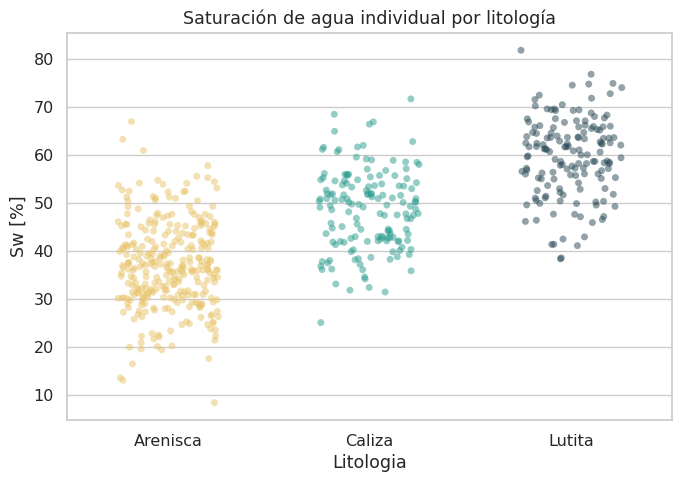

In [90]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.stripplot(data=df_log, x='Litologia', y='Sw_pct', hue='Litologia',
              palette=paleta_litologia, legend=False, alpha=0.5, jitter=0.25, ax=ax)
ax.set_title('Saturación de agua individual por litología')
ax.set_ylabel('Sw [%]')
plt.tight_layout()
plt.show()

**Explicación:** `sns.stripplot` grafica cada muestra individual como un punto, aplicando un pequeño desplazamiento aleatorio horizontal (`jitter`) para que los puntos no se sobrepongan, lo que da una idea más "cruda" (sin resumir) de cuántos datos hay y cómo se dispersan en cada litología.

<table width="100%">
<tr>
<td bgcolor="#E3F2FD">

# <font color="blue">**7. Mapa de calor y clustermap**</font>

</td>
</tr>
</table>

**Teoría**

`sns.heatmap` es el equivalente de `imshow` en Matplotlib pero con anotaciones de texto, barra de color y ticks configurados automáticamente. `sns.clustermap` va un paso más allá: además de dibujar el mapa de calor, agrupa (mediante *clustering* jerárquico) filas y columnas similares entre sí, revelando estructura oculta en los datos.

### 7.1 Matriz de correlación (heatmap)

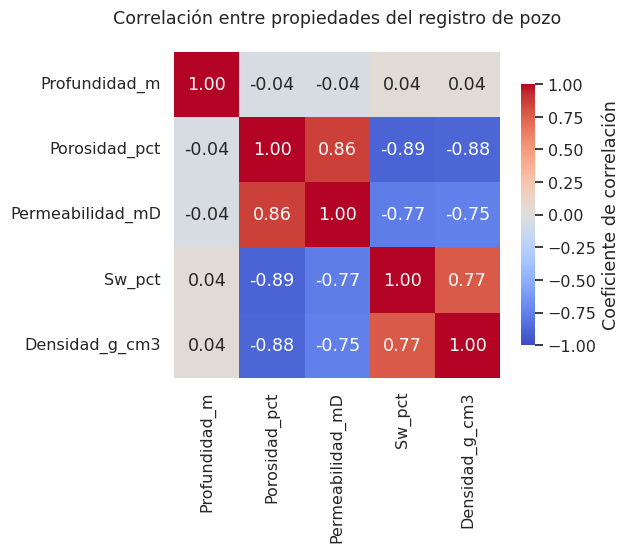

In [91]:
cols_num = ['Profundidad_m', 'Porosidad_pct', 'Permeabilidad_mD', 'Sw_pct', 'Densidad_g_cm3']
corr = df_log[cols_num].corr()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            square=True, cbar_kws={'label': 'Coeficiente de correlación', 'shrink': 0.8}, ax=ax)
ax.set_title('Correlación entre propiedades del registro de pozo', pad=20)
plt.tight_layout()
plt.show()

**Explicación:** se calcula la matriz de correlación entre las propiedades numéricas del registro y se grafica con `sns.heatmap`, que añade automáticamente los valores numéricos (`annot=True`) y la barra de color; `cbar_kws={'shrink': 0.8}` reduce el tamaño de la barra para evitar que se sobreponga con el título, igual que se ajustó en el notebook de Matplotlib.

### 7.2 Agrupamiento jerárquico (clustermap)

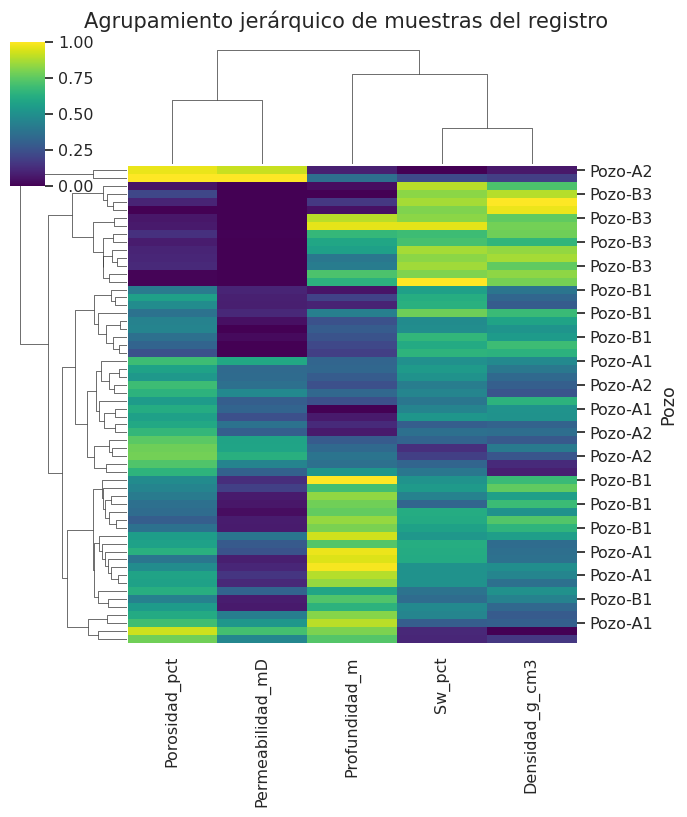

In [92]:
muestra = df_log.sample(60, random_state=1).set_index('Pozo')
datos_cluster = muestra[cols_num]

g = sns.clustermap(datos_cluster, cmap='viridis', standard_scale=1, figsize=(7, 8))
g.fig.suptitle('Agrupamiento jerárquico de muestras del registro', y=1.02)
plt.show()

**Explicación:** se toma una muestra aleatoria de 60 registros, se estandariza cada columna (`standard_scale=1`) y se grafica con `sns.clustermap`, que reordena filas y columnas según un dendrograma de similitud, agrupando visualmente las muestras con propiedades petrofísicas parecidas.

<table width="100%">
<tr>
<td bgcolor="#E3F2FD">

# <font color="blue">**8. Series de tiempo (lineplot)**</font>

</td>
</tr>
</table>

`sns.lineplot` grafica una serie de tiempo y, si hay varias observaciones para el mismo valor de X, calcula automáticamente una banda de confianza. Combinado con `hue`, es una forma muy directa de comparar la evolución temporal de varios pozos en un solo gráfico.

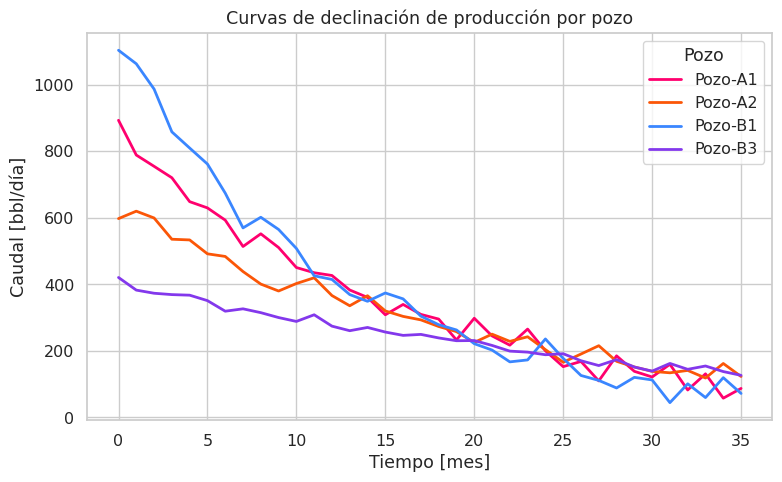

In [93]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=df_produccion, x='Mes', y='Caudal_bbl_dia', hue='Pozo',
             palette=paleta_pozos, linewidth=2, ax=ax)
ax.set_title('Curvas de declinación de producción por pozo')
ax.set_xlabel('Tiempo [mes]')
ax.set_ylabel('Gasto [bbl/día]')
plt.tight_layout()
plt.show()

**Explicación:** se grafica la curva de declinación de los 4 pozos a lo largo de 36 meses; `hue='Pozo'` genera automáticamente una línea de color distinto y una leyenda por pozo, replicando en una sola línea de código lo que en Matplotlib requería varias llamadas a `ax.plot()`.

<table width="100%">
<tr>
<td bgcolor="#E3F2FD">

# <font color="blue">**9. Paneles múltiples (relplot / FacetGrid)**</font>

</td>
</tr>
</table>

`sns.relplot` (y de forma más general `sns.FacetGrid`) permite dividir automáticamente los datos en varios paneles (subgráficos) según una o dos variables categóricas (`col`, `row`), sin necesidad de crear manualmente cada `ax` como en Matplotlib.

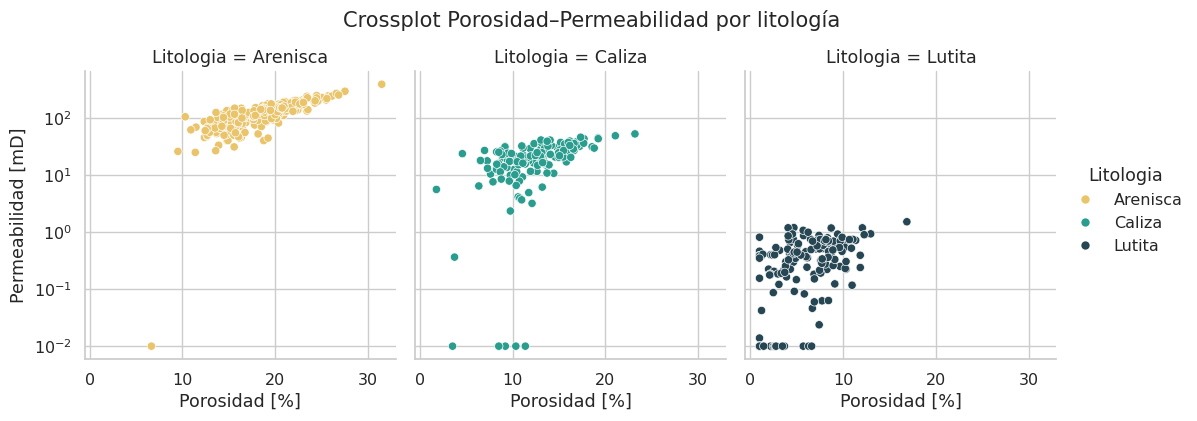

In [94]:
g = sns.relplot(data=df_log, x='Porosidad_pct', y='Permeabilidad_mD', col='Litologia',
                 hue='Litologia', palette=paleta_litologia, kind='scatter', height=4, aspect=0.9)
g.set(yscale='log')
g.set_axis_labels('Porosidad [%]', 'Permeabilidad [mD]')
g.fig.suptitle('Crossplot Porosidad–Permeabilidad por litología', y=1.05)
plt.show()

**Explicación:** `col='Litologia'` separa automáticamente el crossplot en tres paneles, uno por litología, facilitando comparar la relación porosidad-permeabilidad de cada tipo de roca sin que los puntos de las tres litologías se sobrepongan en un mismo gráfico.

<table width="100%">
<tr>
<td bgcolor="#E3F2FD">

# <font color="blue">**10. Crossplot con distribuciones marginales (jointplot)**</font>

</td>
</tr>
</table>

`sns.jointplot` combina un gráfico de dispersión (o de densidad, o hexbin) en el centro con histogramas o curvas KDE en los márgenes superior e inferior, mostrando en una sola figura tanto la relación entre dos variables como su distribución individual.

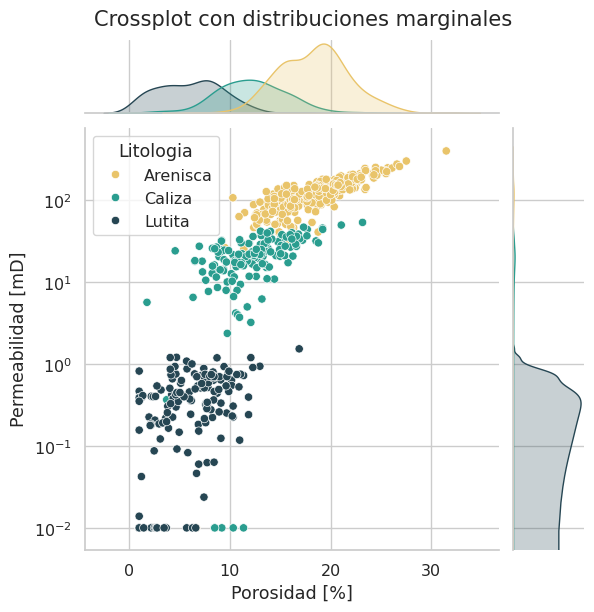

In [95]:
g = sns.jointplot(data=df_log, x='Porosidad_pct', y='Permeabilidad_mD', hue='Litologia',
                   palette=paleta_litologia, height=6)
g.ax_joint.set_yscale('log')
g.set_axis_labels('Porosidad [%]', 'Permeabilidad [mD]')
g.fig.suptitle('Crossplot con distribuciones marginales', y=1.02)
plt.show()

**Explicación:** el panel central muestra el crossplot porosidad-permeabilidad coloreado por litología, mientras que los paneles superior e inferior muestran la distribución marginal de cada variable — útil para detectar de un vistazo tanto la correlación entre variables como posibles sesgos en cada una por separado.

<table width="100%">
<tr>
<td bgcolor="#E3F2FD">

# <font color="blue">**11. Paletas de color personalizadas**</font>

</td>
</tr>
</table>

Además de las paletas predefinidas (`'viridis'`, `'deep'`, `'coolwarm'`, etc.), Seaborn permite construir paletas propias con `sns.color_palette()` a partir de una lista de colores, y visualizarlas antes de usarlas con `sns.palplot()` para elegir la combinación más adecuada.

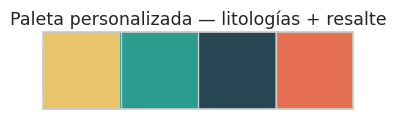

In [96]:
paleta_custom = sns.color_palette(["#E9C46A", "#2A9D8F", "#264653", "#E76F51"])
sns.palplot(paleta_custom)
plt.title('Paleta personalizada — litologías + resalte')
plt.show()

**Explicación:** se construye una paleta personalizada a partir de códigos de color hexadecimales y se visualiza como una franja de colores con `sns.palplot`, un paso útil para validar que la combinación de colores elegida sea clara y estéticamente coherente antes de aplicarla a los gráficos finales.

<table width="100%">
<tr>
<td bgcolor="#E3F2FD">

# <font color="blue">**12. Guardar y exportar gráficos**</font>

</td>
</tr>
</table>

Como los gráficos de Seaborn están construidos sobre Matplotlib, se exportan de la misma manera: con `fig.savefig()` para gráficos creados sobre un `ax`, o con `g.savefig()` cuando se trata de un objeto de figura completa como los que devuelven `pairplot`, `lmplot`, `relplot`, `jointplot` o `clustermap`.

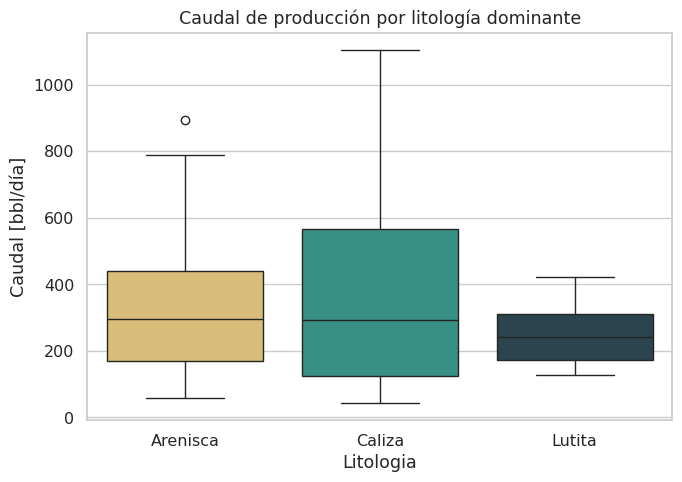

Gráfico guardado como 'produccion_por_litologia.png'


In [97]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df_produccion, x='Litologia', y='Caudal_bbl_dia', hue='Litologia',
            palette=paleta_litologia, legend=False, ax=ax)
ax.set_title('Caudal de producción por litología dominante')
ax.set_ylabel('Caudal [bbl/día]')
plt.tight_layout()

fig.savefig('produccion_por_litologia.png', dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico guardado como 'produccion_por_litologia.png'")

**Explicación:** se guarda la figura como PNG a 300 dpi con `fig.savefig()`, exactamente igual que en Matplotlib, dado que `ax` sigue siendo un objeto de ejes de Matplotlib estándar.

# 13. Comentarios

* Seaborn no reemplaza a Matplotlib, sino que lo complementa: internamente sigue usando `Figure` y `Axes` de Matplotlib, por lo que todo lo aprendido en el notebook anterior (ajustar títulos, ejes, guardar figuras) sigue aplicando directamente.

* Su mayor ventaja es trabajar directamente con DataFrames "en formato largo" (una fila por observación), lo que reduce drásticamente el código necesario para separar series por categoría (`hue`), panel (`col`/`row`) o tamaño (`size`).

* Incluye cálculo estadístico integrado (regresiones, intervalos de confianza, distribuciones KDE), útil para análisis exploratorio rápido, aunque para modelos estadísticos formales sigue siendo necesario usar librerías como `statsmodels` o `scipy`.

* Es especialmente útil en las primeras etapas de un análisis de datos petrofísicos o de producción, cuando se busca identificar rápidamente relaciones, agrupamientos o valores atípicos antes de pasar a un modelado más formal.

* Al igual que Matplotlib, genera imágenes estáticas; para visualizaciones interactivas (zoom, hover, filtros dinámicos) es necesario recurrir a otras librerías como Plotly o Bokeh.